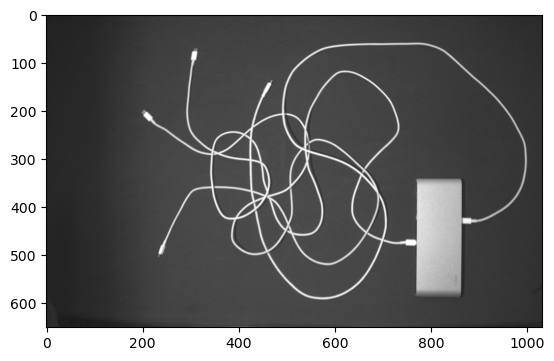

In [1]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

im_frame2 = Image.open('/home/justinyu/multicable-decluttering/decluttering/scripts/test/cable_only_img_depth_pairs/intensity_image2024-06-29T18:00:38.984569.png')
np_frame2 = np.array(im_frame2)

# remove alpha channel
np_frame2 = np_frame2[0:650, :, :3]
# tt_frame2 = torch.tensor(np_frame2).to(torch.uint8)
plt.imshow(np_frame2)

(650, 1032, 3)


/home/justinyu/multicable-decluttering/decluttering/data/detectron2_repo/detectron2/structures/image_list.py:99: UserWarning: __floordiv__ is deprecated, and its behavior will change in a future version of pytorch. It currently rounds toward 0 (like the 'trunc' function NOT 'floor'). This results in incorrect rounding for negative values. To keep the current behavior, use torch.div(a, b, rounding_mode='trunc'), or for actual floor division, use torch.div(a, b, rounding_mode='floor').
  max_size = (max_size + (stride - 1)) // stride * stride


Endpoint detection took 2.602409601211548 seconds


/home/mallika/anaconda3/envs/lipnew/lib/python3.8/site-packages/torch/functional.py:478: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at  /opt/conda/conda-bld/pytorch_1656352465323/work/aten/src/ATen/native/TensorShape.cpp:2894.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


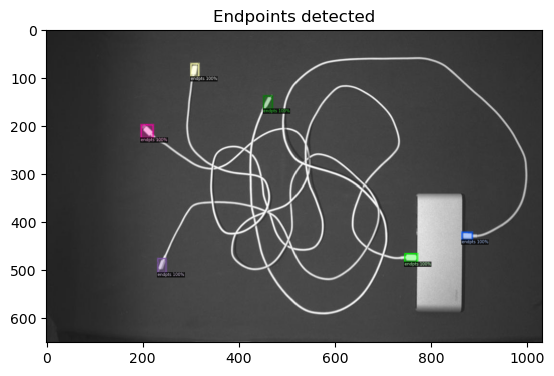

(650, 1032, 3)
300


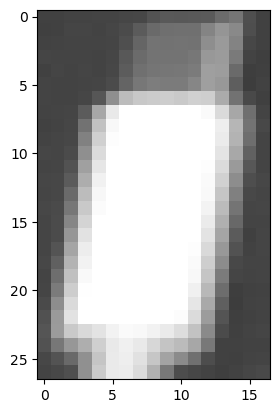

197


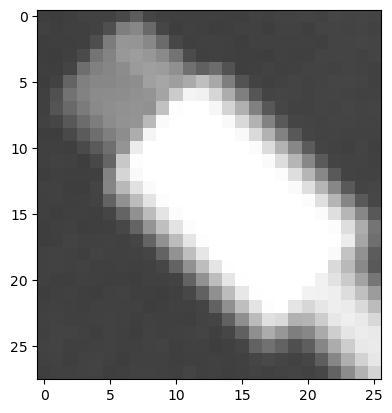

231


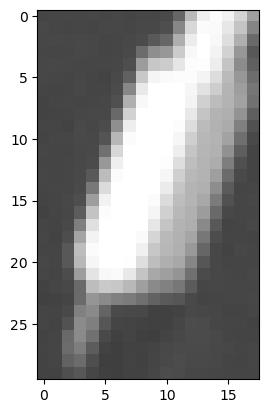

745


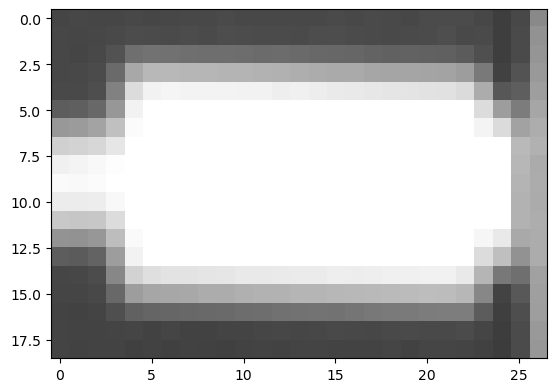

452


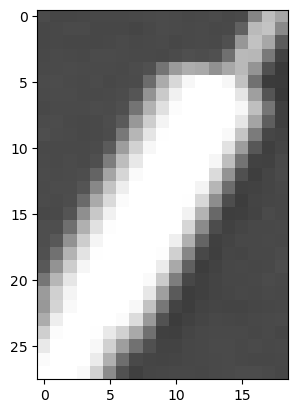

864


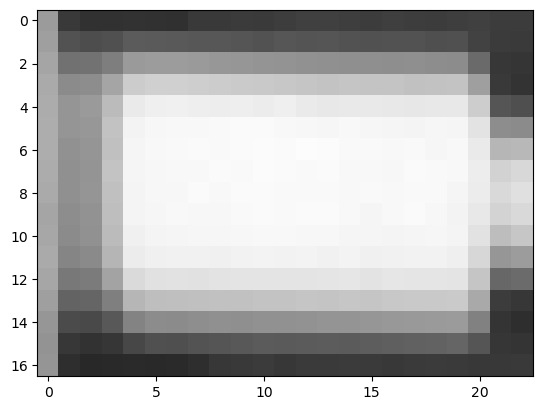

[[ 84 309]
 [212 210]
 [491 240]
 [475 759]
 [152 461]
 [429 876]]


<Figure size 640x480 with 0 Axes>

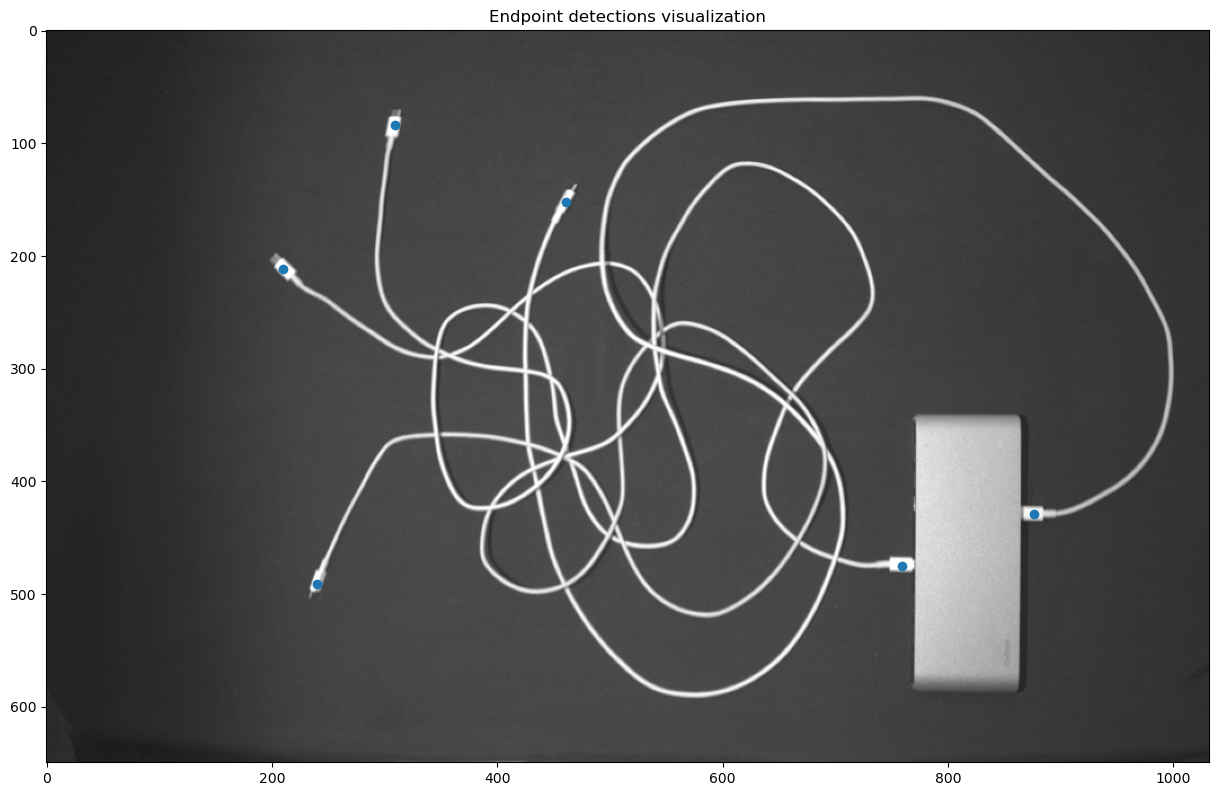

In [2]:
img = np_frame2
from decluttering.data.detectron2_repo import analysis as loop_detectron
import numpy as np 
import time

def get_endpoints(img):
    # model not used, already specified in loop_detectron
    # self.img = self.iface.take_image()
    endpoint_start = time.time()
    endpoint_boxes, out_viz = loop_detectron.predict(img, thresh=0.99, endpoints=True)
    endpoint_end = time.time()
    print("Endpoint detection took {} seconds".format(endpoint_end - endpoint_start))
    plt.clf()
    plt.imshow(out_viz)
    plt.title("Endpoints detected")
    plt.show()
    plt.imsave("/home/justinyu/multicable-decluttering/misc_images/endpoints_detected.png", out_viz)
    print(out_viz.shape)
    # show_img()

    endpoints = []
    for i, box in enumerate(endpoint_boxes):
        xmin, ymin, xmax, ymax = box
        x = (xmin + xmax)/2
        y = (ymin + ymax)/2

        # print(xmin.astype(np.int32))
        # plt.clf()
        # plt.imshow(img[ymin.astype(np.int32):ymax.astype(np.int32), xmin.astype(np.int32):xmax.astype(np.int32)])
        # plt.show()
        # plt.imsave(f"/home/justinyu/multicable-decluttering/misc_images/endpoints_crop{i}.png", img[ymin.astype(np.int32):ymax.astype(np.int32), xmin.astype(np.int32):xmax.astype(np.int32)])
        # new_yx = self.closest_valid_point(self.img.color._data, self.img.depth._data, np.array([y,x]))
        # print(x)
        # print(y)
        # endpoints.append([new_yx, new_yx])
        endpoints.append([y, x])   
    endpoints = np.array(endpoints).astype(np.int32)
    print(endpoints)
    # # (n,2,2) (num endpoints, (head point, neck point), (x,y))
    # endpoints = np.array([e for e in endpoints if self.img.depth._data[e[0][0], e[0][1]] > 0])
    # self.logger.debug("Found {} true endpoints after filtering for depth".format(len(endpoints)))

    plt.clf()
    plt.figure(figsize=(15,18))
    plt.title("Endpoint detections visualization")
    plt.imshow(img)
    if len(endpoints) > 0:
        plt.scatter(endpoints[:, 1], endpoints[:, 0])
    plt.show()
    # self.show_img()

    # endpoints = endpoints.astype(np.int32).reshape(-1, 2, 2)
    # # endpoint1 = endpoints[0][0]
    # # endpoint2 = endpoints[1][0]
    # self.endpoints = endpoints[:, 0, :] #np.array([endpoint1, endpoint2])
    return endpoints

print(img.shape)
endpts = get_endpoints(img)

In [3]:
from decluttering.data.tracer.analytic_tracer.simple_uncertain_trace_single import trace

def analytic_tracer(img, point, keepout_mask=None):
        # trace from endpoint on image
        path, finished_paths = trace(img, point, exact_path_len=3, viz=False, keepout_mask=keepout_mask)
        agree_point = tuple(np.array([point[0], point[1]]).astype(np.int32))
        if path is None:
            if len(finished_paths) > 0:
                min_len_path = float('inf')
                for fp in finished_paths:
                    if len(fp) < min_len_path:
                        min_len_path = len(fp)
                for i in range(min_len_path):
                    values = np.array([list(fp[i]) for fp in finished_paths])
                    x = values[:, 0]
                    y = values[:, 1]
                    x_diff = np.max(x)-np.min(x)
                    y_diff = np.max(y)-np.min(y)
                    if x_diff < 5 and y_diff < 5:
                        agree_point = values[0]
            return agree_point, True
        return path, False



In [4]:
random_endpt = np.random.permutation(len(endpts))[0]

print(np.array(endpts[random_endpt]))

# print(np.array(endpts[0]))
# print(np.array(filtered_endpoint_centers[random_endpt]))

# starting_pixels = analytic_tracer(img, np.array(endpts[0]))

keepout = starting_block.squeeze(0).squeeze(0).unsqueeze(-1).cpu().numpy()
starting_pixels = analytic_tracer(img, np.array(endpts[random_endpt]), keepout_mask=keepout)
print(np.asarray(starting_pixels[0]).astype(int))

[152 461]


NameError: name 'starting_block' is not defined

In [ ]:
from decluttering.data.tracer.blip_pipeline.tracer import run_tracer_with_transform

# run_tracer_with_transform(img, endpts, depth)
# print(starting_pixels[0])
run_tracer_with_transform(img, starting_pixels[0], endpoints=endpts, sample=True, start_time=None, viz = True)

[495 482]
[504.85058361 494.60817206]
[512.36212861 508.73533354]
[517.30640052 523.9522378 ]


((array([[505, 495],
         [512, 509],
         [517, 524],
         [505, 495],
         [512, 509],
         [517, 524],
         [519, 537],
         [521, 550],
         [522, 563],
         [522, 577],
         [521, 591],
         [520, 605],
         [516, 618],
         [510, 629],
         [503, 639],
         [495, 649],
         [488, 659],
         [480, 669],
         [471, 678],
         [463, 687],
         [453, 695],
         [444, 703],
         [434, 710],
         [424, 716],
         [414, 723],
         [404, 729],
         [394, 735],
         [384, 742],
         [374, 749],
         [365, 756],
         [356, 763],
         [346, 770],
         [336, 776],
         [326, 781],
         [314, 785],
         [302, 788],
         [290, 789],
         [278, 790],
         [266, 790],
         [254, 789],
         [242, 788],
         [230, 785],
         [219, 779],
         [209, 772],
         [200, 764],
         [192, 753],
         [186, 742],
         [182